In [1]:
import pandas as pd
from glob import glob
import json
from datetime import datetime
import numpy as np
from itertools import product

# import cf-units aware xarray. needs to be in this order
from xarray import open_mfdataset, open_dataset
import pint
import xarray as xr
import pint_xarray
import cf_xarray as cfxr # not side-effect free
import cf_xarray.units
xr.set_options(keep_attrs=True)
import xesmf as xe
import xcdat # SO many monkey patches

#import cfunits # diffrent packages ;-;
#import cf_units

# note: have to --force-reinstall dask sometimes

In [2]:
starting_year = 1993
last_CDIAC_year = 2021
last_EI_year = 2023

earth_radius = 6371.008 # TODO: decide Earth radius

In [3]:
EI_years = list(range(starting_year, last_EI_year+1))
EI_extrap_years = list(range(last_CDIAC_year, last_EI_year+1)) 

In [4]:
CDIAC_global_xlsx = 'inputs/CDIAC/global.1751_2021.xlsx'
CDIAC_national_xlsx = 'inputs/CDIAC/nation.1751_2021.xlsx'
EI_xlsx = 'inputs/Statistical Review of World Energy Data.xlsx'
EDGAR_ncs = 'inputs/TOTALS_flx_nc_2024_GHG/*.nc'
#EDGAR_ncs = 'inputs/TOTALS_emi_nc_v80/*.nc'
USGS_cement_csvs = './inputs/USGS_cement/mcs????-cement.csv'

### CDIAC at AppState
1. Nation and global annual emissions files
https://rieee.appstate.edu/projects-programs/cdiac/  
https://rieee.appstate.edu/wp-content/uploads/2024/07/global.1751_2020.xlsx  
https://rieee.appstate.edu/wp-content/uploads/2024/07/nation.1751_2020.xlsx  

Based on `read_cdiac_nation_csv.pro`

In [5]:
CDIAC_global = pd.read_excel(CDIAC_global_xlsx, sheet_name='Sheet1')
CDIAC_global = CDIAC_global[CDIAC_global['Year'] >= starting_year].set_index('Year')
CDIAC_col_renames = { # teragrams
   'Total carbon emissions from fossil fuel consumption and cement production (million metric tons of C)':'total (Tg C)',
   'Carbon emissions from solid fuel consumption':'solid_fuel (Tg C)',
   'Carbon emissions from liquid fuel consumption':'liquid_fuel (Tg C)',
   'Carbon emissions from gas fuel consumption':'gas_fuel (Tg C)',
   'Carbon emissions from cement production':'cement (Tg C)',
   'Carbon emissions from gas flaring':'flaring (Tg C)',
   'Per capita carbon emissions (metric tons of carbon; after 1949 only)':'per_capita (Mg C)', # megagrams
}
CDIAC_global.rename(CDIAC_col_renames, axis='columns',inplace=True)
CDIAC_global[['total (Gg C)', 'solid_fuel (Gg C)', 'liquid_fuel (Gg C)', 'gas_fuel (Gg C)', 'cement (Gg C)', 'flaring (Gg C)']] = \
   1000 * CDIAC_global[['total (Tg C)', 'solid_fuel (Tg C)', 'liquid_fuel (Tg C)', 'gas_fuel (Tg C)', 'cement (Tg C)', 'flaring (Tg C)']] # convert to gigagrams (match with national)

CDIAC_global.to_csv('processed_inputs/CDIAC_global_2020.csv', columns=['total (Gg C)','gas_fuel (Gg C)','liquid_fuel (Gg C)','solid_fuel (Gg C)','flaring (Gg C)','cement (Gg C)'])
display(CDIAC_global)

,total (Tg C),solid_fuel (Tg C),liquid_fuel (Tg C),gas_fuel (Tg C),cement (Tg C),flaring (Tg C),per_capita (Mg C),total (Gg C),solid_fuel (Gg C),liquid_fuel (Gg C),gas_fuel (Gg C),cement (Gg C),flaring (Gg C)
Year,,,,,,,,,,,,,
1993,6085,2274,2519,1103,150,39,1.096493,6085000,2274000,2519000,1103000,150000,39000
1994,6130,2292,2536,1103,159,40,1.088133,6130000,2292000,2536000,1103000,159000,40000
1995,6277,2354,2568,1147,168,40,1.097865,6277000,2354000,2568000,1147000,168000,40000
1996,6438,2412,2622,1189,173,41,1.109818,6438000,2412000,2622000,1189000,173000,41000
1997,6502,2400,2686,1200,176,40,1.105060,6502000,2400000,2686000,1200000,176000,40000
1998,6493,2337,2740,1206,174,37,1.088338,6493000,2337000,2740000,1206000,174000,37000
1999,6650,2384,2787,1262,181,37,1.099506,6650000,2384000,2787000,1262000,181000,37000
2000,6812,2456,2819,1303,188,46,1.111237,6812000,2456000,2819000,1303000,188000,46000
2001,6869,2477,2839,1308,197,48,1.105484,6869000,2477000,2839000,1308000,197000,48000


In [6]:
renaming_list = {
    'PLURINATIONAL STATE OF BOLIVIA':'BOLIVIA',
    'HONG KONG SPECIAL ADMINSTRATIVE REGION OF CHINA':'HONG KONG',
    'CHINA (MAINLAND)':'CHINA',
    'MYANMAR (FORMERLY BURMA)':'MYANMAR',
    'BRUNEI (DARUSSALAM)':'BRUNEI',
    'DEMOCRATIC REPUBLIC OF THE CONGO (FORMERLY ZAIRE)':'DEMOCRATIC REPUBLIC OF THE CONGO',
    'FALKLAND ISLANDS (MALVINAS)':'FALKLAND ISLANDS',
    'FRANCE (INCLUDING MONACO)':'FRANCE',
    'LAO PEOPLE S DEMOCRATIC REPUBLIC':'LAOS',
    'LIBYAN ARAB JAMAHIRIYAH':'LIBYA',
    'RUSSIAN FEDERATION':'RUSSIA',
    'SYRIAN ARAB REPUBLIC':'SYRIA',
    'VIET NAM':'VIETNAM',
    'YUGOSLAVIA (MONTENEGRO & SERBIA)':'YUGOSLAVIA',
    'YUGOSLAVIA (FORMER SOCIALIST FEDERAL REPUBLIC)': 'YUGOSLAVIA'
}

# following would be nice to change later, but will screw up list alphabetization...
# ...possibly others too
# REPUBLIC OF CAMEROON
# REPUBLIC OF MOLDOVA
# UNITED REPUBLIC OF TANZANIA

aggregating_list = {
    'ETHIOPIA':['ETHIOPIA', 'ERITREA'],
    'ISRAEL':['ISRAEL', 'OCCUPIED PALESTINIAN TERRITORY'],
    'INDONESIA':['INDONESIA', 'TIMOR-LESTE (FORMERLY EAST TIMOR)'],
    'CANADA':['CANADA', 'ST. PIERRE & MIQUELON'],
    'SPAIN':['SPAIN', 'GIBRALTAR', 'ANDORRA'],
    'VENEZUELA':['VENEZUELA', 'ARUBA'],
    'CHINA':['CHINA', 'MACAU SPECIAL ADMINSTRATIVE REGION OF CHINA'],
    'YUGOSLAVIA':['YUGOSLAVIA', 'MACEDONIA', 'CROATIA','BOSNIA & HERZEGOVINA','SLOVENIA','KOSOVO', 'SERBIA', 'MONTENEGRO'],
    #'YUGOSLAVIA2': ['SERBIA', 'MONTENEGRO'], # Yugoslavia split to Serbia + Montenegro in 2006. Gets seperate entry to preserve per-capita correctly
    # we actually don't care about per-capita
    'SOUTH AFRICA':['SOUTH AFRICA', 'LESOTHO'],
    'UNITED KINGDOM':['UNITED KINGDOM', 'ISLE OF MAN'],
    'ST. KITTS-NEVIS':['ST. KITTS-NEVIS', 'ANGUILLA'],
    'GERMANY':['GERMANY', 'LIECHTENSTEIN'], # TODO: Germany or Switzerland?
    'SUDAN':['REPUBLIC OF SUDAN', 'REPUBLIC OF SOUTH SUDAN'] # Sudan split to Sudan + South Sudan in 2011
}

deleting_list = [
    'CAYMAN ISLANDS','NIUE','MONTSERRAT','PALAU','BRITISH VIRGIN ISLANDS','ANTARCTIC FISHERIES','SAINT HELENA',
    'WALLIS AND FUTUNA ISLANDS','MARSHALL ISLANDS','FEDERATED STATES OF MICRONESIA','TURKS AND CAICOS ISLANDS',
    'BONAIRE, SAINT EUSTATIUS, AND SABA','CURACAO','NETHERLAND ANTILLES','SAINT MARTIN (DUTCH PORTION)','TUVALU','MAYOTTE',
]

CDIAC_col_renames = {
    'Total CO2 emissions from fossil-fuels and cement production (thousand metric tons of C)':'total (Gg C)',
    'Emissions from solid fuel consumption':'solid_fuel (Gg C)',
    'Emissions from liquid fuel consumption':'liquid_fuel (Gg C)',
    'Emissions from gas fuel consumption':'gas_fuel (Gg C)',
    'Emissions from cement production':'cement (Gg C)',
    'Emissions from gas flaring':'flaring (Gg C)',
    'Per capita CO2 emissions (metric tons of carbon)':'per_capita',
    'Emissions from bunker fuels (not included in the totals)':'bunker (Gg C)'
}

# in 2013 version, (BONAIRE, SAINT EUSTATIUS, AND SABA), CURACAO, LICHTENSTEIN, NETHERLAND ANTILLES,SAINT MARTIN (DUTCH PORTION) were added (they do not have full records from 1992 - 2013, which makes
# implementation in ff_country_new20xx.pro difficult.)
# in 2014 version, delete TUVALU
# 
# Liechtenstein now appears fine in CDIAC data that goes through 2017. So merge with Switzerland for now instead of deleting

# NOTE:  The following countries do have GISS codes -- although they may not have full records from 1992 onwards as mentioned above
# Liechtenstein, Netherlands Antilles, Turks and Caicos, Tuvalu

def aggregate_countries(data, little_names, big_name) :
    aggregated = data.xs(key=little_names[0], level="Nation").add(data.xs(key=little_names[1], level="Nation"), fill_value=0)
    for little_name in little_names[2:]:
        aggregated = aggregated.add(data.xs(key=little_name, level="Nation"), fill_value=0)
    aggregated['per_capita'] = data.xs(key=little_names[0], level="Nation")['per_capita'] # intensive, just assume ~first little
    aggregated = pd.concat({big_name: aggregated}, names=['Nation']) # add nation index back in
    return pd.concat([data.drop(little_names, level='Nation'), aggregated]) # remove originals


In [7]:
CDIAC_national = pd.read_excel(CDIAC_national_xlsx, sheet_name='Sheet1').set_index(['Nation', 'Year'])#.fillna(0)

# give countries+cols more standard names
CDIAC_national.rename(renaming_list, level=0, inplace=True)
CDIAC_national.rename(CDIAC_col_renames, axis='columns', inplace=True)

# glomp little countries (e.g. Eritrea) onto neighboring big countries. Also glue Yugoslavia and Sudan back together.
for big, littles in aggregating_list.items():
    CDIAC_national = aggregate_countries(CDIAC_national, littles, big)
CDIAC_national.rename({'YUGOSLAVIA2':'YUGOSLAVIA'}, level=0, inplace=True)

# delete even littler countries
CDIAC_national.drop(deleting_list, level=0, inplace=True)

# only keep data after year countries stablize, fix indices
CDIAC_national.reset_index(inplace=True) 
CDIAC_national['Nation'] = CDIAC_national['Nation'].str.title()
CDIAC_national = CDIAC_national[CDIAC_national['Year'] >= starting_year] 
CDIAC_national.set_index(['Nation', 'Year'], inplace=True)

# French departments are missing values for 2011-2014, so interpolate
for department, year in product(['French Guiana','Guadeloupe','Martinique','Reunion'], [2011, 2012, 2013, 2014]):
    CDIAC_national.loc[(department,year), :] = np.nan 
CDIAC_national.sort_index(axis='index', inplace=True) # needs to be in correct order for interpolation

CDIAC_countries = CDIAC_national.index.get_level_values('Nation').unique().to_series()

# need to ONLY interpolate in a given nation (whoops...)
for nation in CDIAC_national.index.get_level_values('Nation').unique(): # df -> series, fill na, -> df
    CDIAC_national.loc[[nation]] = pd.concat({nation:  CDIAC_national.loc[nation].interpolate()}, names=['Nation'])


# output. Interpolate missing values, then fill extrapolated missing values with zero
CDIAC_national.fillna(0).to_csv('processed_inputs/CDIAC_national_2020.csv', columns=['total (Gg C)','gas_fuel (Gg C)','liquid_fuel (Gg C)','solid_fuel (Gg C)','flaring (Gg C)','cement (Gg C)'])
CDIAC_countries.to_csv('processed_inputs/CDIAC_countries.csv', columns=[], header=False)
display(CDIAC_national) # .xs(key='Gibraltar', level="Nation")

total (Gg C)  solid_fuel (Gg C)  liquid_fuel (Gg C)  \
Nation      Year                                                        
Afghanistan 1993         408.0                5.0               286.0   
            1994         399.0                4.0               281.0   
            1995         389.0                4.0               276.0   
            1996         376.0                2.0               269.0   
            1997         358.0                1.0               259.0   
...                        ...                ...                 ...   
Zimbabwe    2017        2683.0             1638.0               916.0   
            2018        3057.0             1770.0              1135.0   
            2019        2800.0             1641.0              1031.0   
            2020        2326.0             1347.0               836.0   
            2021        2789.0             1620.0              1019.0   

                  gas_fuel (Gg C)  cement (Gg C)  flaring (Gg C)  per_capita  \
Nation      Year                                                               
Afghanistan 1993             96.0           15.0             6.0    0.028914   
            1994             92.0           15.0             6.0    0.025251   
            1995             88.0           15.0             6.0    0.023270   
            1996             84.0           15.0             6.0    0.021580   
            1997             77.0           15.0             6.0    0.019793   
...                           ...            ...             ...         ...   
Zimbabwe    2017              NaN          129.0             NaN    0.182450   
            2018              NaN          151.0             NaN    0.204890   
            2019              NaN          128.0             NaN    0.184866   
            2020              NaN          143.0             NaN    0.151097   
            2021              NaN          149.0             NaN    0.178074   

                  bunker (Gg C)  
Nation      Year                 
Afghanistan 1993            5.0  
            1994            4.0  
            1995            4.0  
            1996            4.0  
            1997            4.0  
...                         ...  
Zimbabwe    2017           36.0  
            2018           44.0  
            2019           44.0  
            2020           15.0  
            2021           32.0  

[5481 rows x 8 columns]

### BP/EI data for extrapolation

https://www.energyinst.org/statistical-review
https://www.energyinst.org/__data/assets/excel_doc/0020/1540550/EI-Stats-Review-All-Data.xlsx

—> use oil, coal, and gas all in energy units — exajoules.

In [8]:
EI_renaming = {
    'China Hong Kong SAR':'Hong Kong',
    'Iran':'Islamic Republic Of Iran',
    'Republic of Ireland':'Ireland',
    'South Korea':'Republic Of Korea',
    'US':'United States Of America',
    'Trinidad & Tobago':'Trinidad And Tobago',
    'Italy':'Italy (Including San Marino)',
    'Russian Federation':'Russia',
    'Brunei (Darussalam)':'Brunei',
    'Democratic Republic Of The Congo (Formerly Zaire)' : 'Democratic Republic Of The Congo',
    'Falkland Islands (Malvinas)': 'Falkland Islands',
    'North Macedonia': 'Macedonia'
}

#### Global (for extrapolation)

In [9]:
global_oil =  pd.read_excel(EI_xlsx, sheet_name='Primary energy cons - EJ', header=2, index_col=0, skipfooter=10).loc['Total World'].drop(['2023.1', '2023.2', '2013-23'])
global_gas = pd.read_excel(EI_xlsx, sheet_name='Gas Consumption - EJ', header=2, index_col=0, skipfooter=13).loc['Total World'].drop(['2023.1', '2023.2', '2013-23'])
global_coal = pd.read_excel(EI_xlsx, sheet_name='Coal Consumption - EJ', header=2, index_col=0, skipfooter=12).loc['Total World'].drop(['2023.1', '2023.2', '2013-23'])
global_flaring = pd.read_excel(EI_xlsx, sheet_name='CO2 From Flaring', index_col=0, header=2, skipfooter=12).loc['Total World'].drop(['2023.1', '2023.2', '2013-23'])

global_EI = pd.concat([global_oil,global_gas,global_coal, global_flaring], axis=1, keys=['oil', 'gas', 'coal', 'flaring']).stack().unstack(0)
display(global_EI)

,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
oil,156.100928,164.640358,170.681279,180.891142,193.324256,205.796156,213.979022,225.71991,238.786576,240.086755,...,543.207637,547.327784,552.987841,566.107432,581.466395,588.04773,567.603829,596.624528,607.349529,619.628657
gas,22.693754,24.727732,26.54661,28.959651,31.800361,34.61331,37.055484,39.102168,40.960198,41.975493,...,122.262116,125.1076,126.825657,131.463256,137.957184,140.704034,139.370733,144.860461,144.312764,144.366257
coal,58.239702,58.89395,57.943864,58.799318,60.6492,61.513216,61.150996,61.805614,63.66085,63.707153,...,161.615422,157.249824,153.8527,155.495817,157.870059,156.949795,152.268069,160.560291,161.528843,164.033746
flaring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,305.572488,308.970433,315.153329,298.093872,305.038846,316.826713,300.492453,308.313574,296.57517,317.357625


In [10]:
(global_oil.pct_change() + 1).dropna().to_csv('processed_inputs/EI_frac_changes_2020-2023_global_oil.csv', index=False)
(global_gas.pct_change() + 1).dropna().to_csv('processed_inputs/EI_frac_changes_2020-2023_global_gas.csv', index=False)
(global_coal.pct_change() + 1).dropna().to_csv('processed_inputs/EI_frac_changes_2020-2023_global_coal.csv', index=False)

/var/folders/s6/h6lpg28j60s5pprqfp_k25ww0010hy/T/ipykernel_45550/371275991.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (global_oil.pct_change() + 1).dropna().to_csv('processed_inputs/EI_frac_changes_2020-2023_global_oil.csv', index=False)
/var/folders/s6/h6lpg28j60s5pprqfp_k25ww0010hy/T/ipykernel_45550/371275991.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (global_gas.pct_change() + 1).dropna().to_csv('processed_inputs/EI_frac_changes_2020-2023_global_gas.csv', index=False)
/var/folders/s6/h6lpg28j60s5pprqfp_k25ww0010hy/T/ipykernel_45550/3

#### Flaring

In [11]:
# flaring has a diffrent country set, so treat separately
EI_flaring = pd.read_excel(EI_xlsx, sheet_name='CO2 From Flaring', index_col=0, header=2, skipfooter=12).dropna(axis='index', how='all').dropna(axis='columns', how='all')
EI_flaring.index.names = ['Nation']
EI_flaring.rename(EI_renaming, level='Nation', inplace=True)
EI_flaring.reset_index(inplace=True)
EI_flaring = EI_flaring[~EI_flaring['Nation'].str.startswith('Total')].set_index('Nation') # remove totals

display(EI_flaring.head())

,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,...,2017,2018,2019,2020,2021,2022,2023,2023.1,2013-23,2023.2
Nation,,,,,,,,,,,,,,,,,,,,,
Canada,2.796136,2.540152,2.441696,2.638607,3.150576,2.402314,2.973356,2.993047,3.150576,4.371424,...,2.852936,2.864096,2.316929,2.519649,2.537728,2.291340,2.600986,0.135138,-0.023747,0.008196
Mexico,10.534738,10.318136,8.033969,14.532032,7.403854,8.703466,13.960990,12.996126,8.841304,6.183005,...,9.129053,9.153111,10.675764,13.531135,15.841326,13.768443,14.441191,0.048862,0.033893,0.045504
United States Of America,7.462927,7.364471,7.620456,8.545937,9.313890,6.970649,5.474126,5.178759,5.296906,6.025477,...,19.459106,28.553528,34.901289,24.970381,19.552848,17.734205,21.023906,0.1855,0.011526,0.066247
Argentina,4.686482,5.218141,5.867948,6.005785,7.285707,7.069105,5.907330,6.399608,5.966403,7.167560,...,1.201839,1.562835,2.030806,2.315138,2.704736,2.499424,2.376087,-0.049346,0.040062,0.007487
Bolivia,0.925482,1.161775,0.728571,0.787644,0.590733,0.393822,0.393822,0.315058,0.374131,0.295366,...,0.069724,0.076804,0.084479,0.116345,0.094322,0.110749,0.102651,-0.073119,0.012857,0.000323


In [12]:
with open('EI_2024_flaring_regions.json') as f:
    EI_flaring_regions = json.load(f)

# No Macedonia, Slovenia, Croatia, or USSR to worry about

# take region e.g. Other Europe, copy values to all countries inside it, and remove
for EI_label, CDIAC_countries in EI_flaring_regions.items():
    for CDIAC_country in CDIAC_countries:
        EI_flaring.loc[CDIAC_country, :] = EI_flaring.loc[EI_label, :]
EI_flaring.drop(EI_flaring_regions.keys(), inplace=True)

EI_flaring.reset_index(inplace=True)
EI_flaring['Nation'] = EI_flaring['Nation'].str.title()
EI_flaring.set_index('Nation',inplace=True)
EI_flaring.sort_index(inplace=True)

display(EI_flaring)

,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,...,2017,2018,2019,2020,2021,2022,2023,2023.1,2013-23,2023.2
Nation,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.934216,0.884186,0.592408,0.631485,0.775344,0.889208,0.750537,-0.155949,-0.057565,0.002365
Albania,0.000000,0.000000,0.000000,0.000000,0.000000,0.039382,0.000000,0.000000,0.000000,0.000000,...,0.634327,0.741920,0.878514,0.809088,0.844115,0.717042,0.731337,0.019935,-0.020053,0.002304
Algeria,15.142456,20.951330,23.117351,24.101906,19.730482,19.120058,13.252110,9.491110,8.605011,11.243618,...,18.640223,18.991098,19.641508,18.799438,16.390849,17.252912,16.727406,-0.030459,-0.006354,0.052708
Angola,7.777984,6.832812,8.880686,7.777985,8.605011,8.388409,8.920068,8.506555,8.073351,8.664084,...,18.895695,17.259166,16.540791,15.803399,14.961847,15.934897,14.487506,-0.090832,-0.025352,0.045650
Antigua & Barbuda,0.531660,0.511969,0.610424,0.610424,0.689188,0.689188,0.649806,0.630115,0.649806,0.787644,...,2.556010,2.255382,2.252246,3.055011,3.189681,3.426764,3.910325,0.141113,0.06562,0.012322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vietnam,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.924242,1.563527,1.566529,1.358679,1.148207,1.168529,1.335238,0.142665,-0.045565,0.004207
Yemen,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-,-,0.000000
Yugoslavia,0.000000,0.000000,0.000000,0.000000,0.000000,0.039382,0.000000,0.000000,0.000000,0.000000,...,0.634327,0.741920,0.878514,0.809088,0.844115,0.717042,0.731337,0.019935,-0.020053,0.002304


#### Oil, gas, and coal

In [13]:
# diffrent footer amounts to remove comments and world totals
EI_oil = pd.read_excel(EI_xlsx, sheet_name='Primary energy cons - EJ', header=2, index_col=0, skipfooter=10).dropna(axis='index', how='all').dropna(axis='columns', how='all')
EI_gas = pd.read_excel(EI_xlsx, sheet_name='Gas Consumption - EJ', header=2, index_col=0, skipfooter=13).dropna(axis='index', how='all').dropna(axis='columns', how='all')
EI_coal = pd.read_excel(EI_xlsx, sheet_name='Coal Consumption - EJ', header=2, index_col=0, skipfooter=12).dropna(axis='index', how='all').dropna(axis='columns', how='all')

In [14]:
EI_fuels = pd.concat({'oil': EI_oil, 'coal': EI_coal, 'gas': EI_gas}, names=['Fuel_type'])
EI_fuels.index.names = ['Fuel_type', 'Nation']

EI_fuels.rename(EI_renaming, level='Nation', inplace=True)
#EI_fuels = EI_fuels[EI_years] # only keep EI years (e.g. 1993 - 2023)
EI_fuels = EI_fuels[~EI_fuels.index.get_level_values('Nation').str.startswith('Total')] # remove totals
EI_fuels.reset_index('Nation', inplace=True)

# we put Macedonia, Slovenia, and Croatia in Yugoslavia, which is in 'other Europe', so combine there
yugoslavia_extras = EI_fuels[EI_fuels['Nation'] == 'Macedonia'].add(EI_fuels[EI_fuels['Nation'] == 'Slovenia'].add(EI_fuels[EI_fuels['Nation'] == 'Croatia']))
yugoslavia_extras['Nation'] = ''
EI_fuels[EI_fuels['Nation'] == 'Other Europe'] = EI_fuels[EI_fuels['Nation'] == 'Other Europe'].add(yugoslavia_extras)
EI_fuels = EI_fuels.reset_index('Fuel_type').set_index('Nation')
EI_fuels.drop(['Macedonia', 'Slovenia', 'Croatia', 'USSR'], axis='index', inplace=True)# also remove the USSR

EI_fuels = EI_fuels.reset_index().set_index(['Nation', 'Fuel_type'])
EI_fuels.sort_index(inplace=True)
EI_fuels

1965      1966      1967      1968      1969  \
Nation         Fuel_type                                                     
Algeria        coal       0.002931  0.002847  0.002177  0.002303  0.002931   
               gas        0.026750  0.027789  0.026958  0.028344  0.037266   
               oil        0.089398  0.107397  0.101691  0.109242  0.120741   
Argentina      coal       0.030438  0.025099  0.028225  0.027429  0.032840   
               gas        0.148442  0.160766  0.168118  0.187198  0.186498   
...                            ...       ...       ...       ...       ...   
Vietnam        gas        0.000000  0.000000  0.000000  0.000000  0.000000   
               oil        0.106038  0.185335  0.255387  0.264838  0.312805   
Western Africa coal       0.019767  0.018706  0.008826  0.001528  0.001868   
               gas        0.003440  0.006179  0.006356  0.005162  0.002245   
               oil        0.207097  0.219226  0.225005  0.235339  0.260801   

                              1970      1971      1972      1973      1974  \
Nation         Fuel_type                                                     
Algeria        coal       0.003475  0.000963  0.000837  0.000963  0.000795   
               gas        0.035031  0.039778  0.046188  0.064293  0.074428   
               oil        0.132332  0.143038  0.160732  0.191702  0.212072   
Argentina      coal       0.042201  0.036999  0.031145  0.034187  0.042573   
               gas        0.210760  0.227530  0.255328  0.290548  0.307528   
...                            ...       ...       ...       ...       ...   
Vietnam        gas        0.000000  0.000000  0.000000  0.000000  0.000000   
               oil        0.326316  0.290969  0.282004  0.297637  0.221365   
Western Africa coal       0.003337  0.006509  0.008489  0.008635  0.007018   
               gas        0.003796  0.007028  0.009422  0.014432  0.013475   
               oil        0.283138  0.342974  0.368220  0.417732  0.434819   

                          ...      2017      2018      2019      2020  \
Nation         Fuel_type  ...                                           
Algeria        coal       ...  0.007620  0.020934  0.017291  0.005485   
               gas        ...  1.420650  1.562715  1.621966  1.560601   
               oil        ...  2.245661  2.410631  2.499656  2.336036   
Argentina      coal       ...  0.045091  0.049353  0.029246  0.036055   
               gas        ...  1.738801  1.753277  1.676121  1.581525   
...                       ...       ...       ...       ...       ...   
Vietnam        gas        ...  0.342745  0.347747  0.354348  0.318218   
               oil        ...  3.469074  3.899785  4.329488  4.335817   
Western Africa coal       ...  0.052337  0.048113  0.051770  0.053958   
               gas        ...  0.794929  0.849432  0.874294  0.934413   
               oil        ...  2.407582  2.695213  2.774923  2.810516   

                              2021      2022      2023    2023.1   2013-23  \
Nation         Fuel_type                                                     
Algeria        coal       0.011179  0.007829  0.006959 -0.111194  0.005352   
               gas        1.733505  1.812195  1.666665 -0.080306   0.03723   
               oil        2.547458  2.643088  2.538010 -0.039756  0.027599   
Argentina      coal       0.050589  0.053610  0.046057 -0.140874 -0.015115   
               gas        1.653627  1.650702  1.617710 -0.019986 -0.002397   
...                            ...       ...       ...       ...       ...   
Vietnam        gas        0.259160  0.280699  0.259855 -0.074257 -0.026165   
               oil        4.350794  4.478643  4.891435  0.092169  0.074975   
Western Africa coal       0.074980  0.068911  0.065058  -0.05591  0.139231   
               gas        1.241409  1.189070  1.152401 -0.030839  0.097078   
               oil        3.311810  3.340782  3.270162 -0.021139  0.059456   

                            2023.2 

In [15]:
# NOTE: Afghanistan moved to 'Other Asia Pacific', in accordance with EI Definitions tab
with open('EI_2024_fuel_regions.json') as f:
    EI_fuel_regions = json.load(f)

In [16]:
# checks that countries are appropriately represented in CDIAC, EI, and extras
all_extras = []
for nations in EI_fuel_regions.values():
    all_extras += nations
    
Extra_counties = set(all_extras)
CDIAC_countries = set(CDIAC_national.index.get_level_values(0).str.title().unique())
EI_countries = set(EI_fuels.index.get_level_values(0).str.title().unique())

# should both be emtpy sets
missing_countries = ( CDIAC_countries - EI_countries) - Extra_counties
duplicate_countries = Extra_counties - (CDIAC_countries - EI_countries)
display(missing_countries, duplicate_countries)

set()

set()

In [17]:
# take region e.g. Middle Africa, copy values to all countries inside it, and remove
for EI_label, CDIAC_nations in EI_fuel_regions.items():
    for CDIAC_country in CDIAC_nations:
        dupe = pd.concat({CDIAC_country: EI_fuels.loc[EI_label]}, names=['Nation'])
        EI_fuels = pd.concat([EI_fuels, dupe])

EI_fuels.sort_index(inplace=True)
EI_fuels.drop(EI_fuel_regions.keys(), inplace=True)

EI_fuels.reset_index(inplace=True)
EI_fuels['Nation'] = EI_fuels['Nation'].str.title()
EI_fuels.set_index(['Nation', 'Fuel_type'], inplace=True)
EI_fuels

1965      1966      1967      1968      1969  \
Nation      Fuel_type                                                     
Afghanistan coal       0.453470  0.485889  0.532012  0.581748  0.625033   
            gas        0.008383  0.010743  0.016387  0.019304  0.020505   
            oil        0.723694  0.764733  0.826610  0.886221  0.938405   
Albania     coal       0.379123  0.370488  0.323835  0.337931  0.333010   
            gas        0.012454  0.015229  0.017624  0.022028  0.027316   
...                         ...       ...       ...       ...       ...   
Zambia      gas        0.000000  0.000033  0.000033  0.000033  0.000033   
            oil        0.393084  0.429445  0.445847  0.461663  0.496000   
Zimbabwe    coal       0.075891  0.088309  0.089172  0.093981  0.091165   
            gas        0.000000  0.000033  0.000033  0.000033  0.000033   
            oil        0.393084  0.429445  0.445847  0.461663  0.496000   

                           1970      1971      1972      1973      1974  ...  \
Nation      Fuel_type                                                    ...   
Afghanistan coal       0.676169  0.760526  0.777986  0.795104  0.826050  ...   
            gas        0.021431  0.022518  0.018627  0.040817  0.066081  ...   
            oil        0.999461  1.094380  1.155096  1.189919  1.272770  ...   
Albania     coal       0.349522  0.386355  0.377800  0.396972  0.408220  ...   
            gas        0.035896  0.042662  0.052318  0.056924  0.062247  ...   
...                         ...       ...       ...       ...       ...  ...   
Zambia      gas        0.000033  0.000033  0.000033  0.000033  0.000033  ...   
            oil        0.557849  0.561504  0.581229  0.614838  0.641274  ...   
Zimbabwe    coal       0.103222  0.105237  0.098184  0.107836  0.099288  ...   
            gas        0.000033  0.000033  0.000033  0.000033  0.000033  ...   
            oil        0.557849  0.561504  0.581229  0.614838  0.641274  ...   

                           2017      2018      2019      2020      2021  \
Nation      Fuel_type                                                     
Afghanistan coal       1.151994  1.128681  1.257383  1.225839  1.125975   
            gas        0.406430  0.391611  0.411438  0.438392  0.428291   
            oil        3.152431  3.275469  3.453018  3.551571  3.539151   
Albania     coal       0.698065  0.686122  0.675127  0.676114  0.641059   
            gas        0.336106  0.327387  0.339236  0.344564  0.372671   
...                         ...       ...       ...       ...       ...   
Zambia      gas        0.072844  0.075623  0.086378  0.082900  0.096207   
            oil        2.245541  2.374896  2.359461  2.288649  2.446806   
Zimbabwe    coal       0.199291  0.222709  0.183814  0.180682  0.199885   
            gas        0.072844  0.075623  0.086378  0.082900  0.096207   
            oil        2.245541  2.374896  2.359461  2.288649  2.446806   

                           2022      2023    2023.1   2013-23    2023.2  
Nation      Fuel_type                                                    
Afghanistan coal       1.170654  1.274014  0.088292  0.087885  0.007767  
            gas        0.403080  0.406976  0.009665  0.027562  0.002819  
            oil        3.700946  3.829196  0.034653  0.059727  0.006180  
Albania     coal       0.626363  0.592109 -0.260657 -0.175251  0.003610  
            gas        0.368369  0.381068  0.281908  0.129732  0.002640  
...                         ...       ...       ...       ...       ...  
Zambia      gas        0.102881  0.105981  0.030125  0.099285  0.000734  
            oil        2.405109  2.468343  0.026292  0.027996  0.003984  
Zimbabwe    coal       0.219411  0.244851  0.115948  0.043898  0.001493  
            gas        0.102881  0.105981  0.030125  0.099285  0.000734  
            oil        2.405109  2.468343  0.026292  0.027996  0.003984  

[567 rows x 62 columns]

#### Combine Flaring with others

In [18]:
EI_combined = EI_fuels.reset_index().set_index(['Fuel_type', 'Nation']).sort_index()
x = pd.concat([EI_flaring], keys=['flaring'], names=['Fuel_type'])
EI_combined = pd.concat([EI_combined, x]).reset_index()
EI_combined = EI_combined.set_index(['Nation', 'Fuel_type']).sort_index()
EI_combined.loc['Spain', 'flaring'] += EI_combined.loc['Gibraltar', 'flaring'] # glomp Gibralter (only flaring) onto Spain 
EI_combined.drop('Gibraltar', axis='index', level='Nation', inplace=True)


EI_combined_ranged = EI_combined[EI_years]
EI_csv = EI_combined_ranged.stack().unstack(level='Fuel_type').rename(columns={'coal':'coal (EJ)', 'flaring':'flaring (TG CO2)', 'oil':'oil (EJ)', 'gas':'gas (EJ)'}) # transpose fuel_type to columns

EI_csv.to_csv('processed_inputs/EI_national_2023.csv')

#### Ratios for extrapolation

In [19]:
fractional_changes = EI_combined[[last_CDIAC_year-1] + EI_extrap_years].stack().unstack(level=1).groupby(level='Nation').pct_change().drop(labels=last_CDIAC_year-1, level=1).replace([np.inf, -np.inf], np.nan) + 1

global_fractional_changes = global_EI.T.pct_change().T[EI_extrap_years].T

for nation in fractional_changes.index.get_level_values('Nation').unique(): # df -> series, fill na, -> df
    fractional_changes.loc[[nation]] = pd.concat({nation:  fractional_changes.loc[nation].fillna(global_fractional_changes)}, names=['Nation'])

fractional_changes['gas'].unstack().drop(['Ussr']).to_csv('processed_inputs/EI_frac_changes_2020-2023_gas.csv')
fractional_changes['coal'].unstack().drop(['Ussr']).to_csv('processed_inputs/EI_frac_changes_2020-2023_coal.csv')
fractional_changes['oil'].unstack().drop(['Ussr']).to_csv('processed_inputs/EI_frac_changes_2020-2023_oil.csv')
display(fractional_changes)


/var/folders/s6/h6lpg28j60s5pprqfp_k25ww0010hy/T/ipykernel_45550/336240162.py:1: FutureWarning: The default fill_method='ffill' in DataFrameGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fractional_changes = EI_combined[[last_CDIAC_year-1] + EI_extrap_years].stack().unstack(level=1).groupby(level='Nation').pct_change().drop(labels=last_CDIAC_year-1, level=1).replace([np.inf, -np.inf], np.nan) + 1
/var/folders/s6/h6lpg28j60s5pprqfp_k25ww0010hy/T/ipykernel_45550/336240162.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  global_fractional_changes = global_EI.T.pct_change().T[EI_extrap_years].T


Fuel_type             coal   flaring       gas       oil
Nation                                                  
Afghanistan 2021  0.918534  1.227810  0.976959  0.996503
            2022  1.039681  1.146857  0.941137  1.045716
            2023  1.088292  0.844051  1.009665  1.034653
Albania     2021  0.948151  1.043292  1.081574  1.062244
            2022  0.977076  0.849460  0.988456  0.975363
...                    ...       ...       ...       ...
Zambia      2022  1.097688  1.065035  1.069379  0.982959
            2023  1.115948  0.909168  1.030125  1.026292
Zimbabwe    2021  1.106278  0.946749  1.160511  1.069105
            2022  1.097688  1.065035  1.069379  0.982959
            2023  1.115948  0.909168  1.030125  1.026292

[570 rows x 4 columns]

### USGS Cement
https://www.usgs.gov/centers/national-minerals-information-center/cement-statistics-and-information

In [20]:
USGS_renames = {
    'United States (includes Puerto Rico)':'United States of America',
    'Korea Republic of':'Republic of Korea'
}

# these CSVs are constucted by manually reading the PDF
cement_datas = []
for cement_datafile in sorted(glob(USGS_cement_csvs)):
    cement_data = pd.read_csv(cement_datafile)
    cement_data.columns = cement_data.columns.str.replace(' (Gg)', '')
    cement_data = pd.wide_to_long(cement_data, ['Cement', 'Clinker'], i='Nation', j='Year', sep=' ')
    cement_datas.append(cement_data)
    
total_cement = pd.concat(cement_datas).sort_index().rename(USGS_renames, axis='index')
total_cement = total_cement.reset_index().drop_duplicates(subset=['Nation', 'Year'], keep='last').set_index(['Nation', 'Year']).sort_index()

total_cement.to_csv('./processed_inputs/USGS_cement_2025a.csv')

In [21]:
cement_ratios = total_cement.drop(columns='Clinker').drop(labels='World total (rounded)').stack().unstack(level='Year')
cement_ratios = cement_ratios.div(cement_ratios[2020], axis=0).dropna(how='all')
cement_other_nations = cement_ratios.xs('Other countries (rounded)').reset_index()
cement_ratios = cement_ratios.reset_index().drop(columns=['level_1'])

new_rows = []
for CDIAC_country in CDIAC_countries:
    if not (CDIAC_country in list(cement_ratios['Nation'])):
        temp = cement_other_nations.copy()
        temp['Nation'] = CDIAC_country
        new_rows.append(temp)

cement_ratios = pd.concat([cement_ratios, *new_rows]).set_index('Nation').sort_index()
cement_ratios = cement_ratios.drop('Other countries (rounded)').drop(columns=['index', 2018, 2019])
cement_ratios = cement_ratios.stack('Year').to_frame()
cement_ratios.columns = ['cement']
cement_ratios.to_csv('processed_inputs/USGS_cement_ratios_2020-2025a.csv')
display(cement_ratios)

cement
Nation      Year          
Afghanistan 2006  0.496629
            2007  0.438202
            2008  0.515730
            2009  0.505618
            2010  0.539326
...                    ...
Zimbabwe    2020  1.000000
            2021  0.955056
            2022  0.955056
            2023  0.955056
            2024  0.966292

[3264 rows x 1 columns]

### EDGAR emissions for spatial patterning
https://edgar.jrc.ec.europa.eu/gallery?release=v2024ghg&substance=CO2&sector=TOTALS  
https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/EDGAR/datasets/EDGAR_2024_GHG/CO2/TOTALS/TOTALS_flx_nc.zip

EDGAR v8 is quite different from EDGAR_GHG_2024, so needs different processing

In [22]:
print(sorted(glob(EDGAR_ncs)))

['inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1970_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1971_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1972_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1973_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1974_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1975_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1976_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1977_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1978_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1979_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1980_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1981_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1982_TOTALS_flx.nc', 'inputs/TOTALS_flx_nc_2024_GHG/EDGAR_2024_GHG_CO2_1983_TOTALS_flx.nc', 'inpu

/opt/anaconda3/envs/p310/lib/python3.10/site-packages/xesmf/util.py:157: UserWarning: 360 cannot be divided by d_lon = 0.1, might not cover the globe uniformly
  warnings.warn(
/opt/anaconda3/envs/p310/lib/python3.10/site-packages/xesmf/util.py:163: UserWarning: 180 cannot be divided by d_lat = 0.1, might not cover the globe uniformly
  warnings.warn(


<xarray.Dataset> Size: 3GB
Dimensions:           (lat: 1800, lon: 3600, year: 33)
Coordinates:
  * lat               (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.85 89.95
  * lon               (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9
  * year              (year) int64 264B 1993 1994 1995 1996 ... 2023 2024 2025
Data variables:
    fluxes            (year, lat, lon) float32 855MB [kg/m²/s] dask.array<get...
    01x01 areas       (lat, lon) float64 52MB [km²] 0.1079 0.1079 ... 0.1079
    seconds_per_year  (year) float64 264B [s] 3.154e+07 3.154e+07 ... 3.154e+07
    emissions         (year, lat, lon) float64 2GB [kg·km²/m²] dask.array<mul...
Attributes:
    description:       TOTALS
    institution:       European Commission, Joint Research Centre
    source:            https://edgar.jrc.ec.europa.eu/dataset_ghg2024
    how_to_cite:       https://edgar.jrc.ec.europa.eu/dataset_ghg2024#howtocite
    copyright_notice:  https://edgar.jrc.ec.europa.eu/dataset_ghg2024#conditions
    contacts:          https://edgar.jrc.ec.europa.eu/dataset_ghg2024#info JR...
    units:             kg m-2 s-1

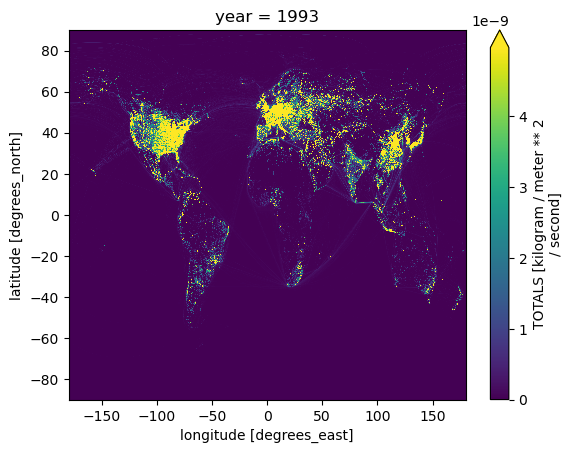

In [23]:
grid_1x1 = xe.util.grid_global(1, 1, cf=True)
grid_1x1_areas = xe.util.cell_area(grid_1x1, earth_radius=earth_radius)

grid_01x01 = xe.util.grid_global(.1, .1, cf=True)
grid_01x01_areas = xe.util.cell_area(grid_01x01, earth_radius=earth_radius)

def add_id(ds):
    ds.coords['year'] = int(ds.variables['fluxes'].attrs['year'])
    return ds

def seconds_in_year(year): # since it changes per year. NOTE: doesn't handle leap seconds correctly (unix just smears them). Probably doesn't matter.
    return (datetime(year+1, 1, 1, 0, 0, 0).timestamp() - datetime(year, 1, 1, 0, 0, 0).timestamp()) 

# note: duplicated 2023 for 2024 and 2025
EDGAR_flux_all_years = open_mfdataset(sorted(glob(EDGAR_ncs)), preprocess=add_id, combine='nested', concat_dim='year')
EDGAR_flux_all_years['fluxes'] = EDGAR_flux_all_years['fluxes'].pint.quantify(EDGAR_flux_all_years['fluxes'].attrs['units']) #  pint.Unit('Mg')
# TODO: move secs_per_year to here

starting_index = list(EDGAR_flux_all_years['year']).index(starting_year)
EDGAR_flux = xr.Dataset()
EDGAR_flux['fluxes'] = EDGAR_flux_all_years['fluxes'][starting_index:, : :]
EDGAR_flux['01x01 areas'] = xr.DataArray(grid_01x01_areas.to_numpy(), dims=['lat','lon']).pint.quantify('km^2') # force floating point lat/lon to line up
EDGAR_flux['seconds_per_year'] = xr.DataArray(np.array([seconds_in_year(int(year)) for year in EDGAR_flux['year']]) * cf_xarray.units.units('s'), dims='year')
EDGAR_flux['emissions'] = EDGAR_flux['fluxes'] * EDGAR_flux['01x01 areas'] * EDGAR_flux['seconds_per_year']
#EDGAR_flux['flux'] = EDGAR_flux['fluxes'] #EDGAR_flux['emissions'] / EDGAR_flux['01x01 areas'] / EDGAR_flux['seconds_per_year']
EDGAR_flux.attrs = EDGAR_flux_all_years.attrs

EDGAR_flux['fluxes'][0,:,:].plot(robust=True)

display(EDGAR_flux)

In [24]:
# regrid to 1x1. takes 50 seconds.
# strip units for regridder, then re-add them
#regridder = xe.Regridder(EDGAR_flux['emissions'][0,:,:].pint.dequantify(), grid_1x1, "conservative", periodic=True) # expensive part

Magnitude,[[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.635738269896689 1.0724917507817606 0.37002083978734346 ... 1.2866304565093258 0.3341457028836312 0.7221530153391496] [0.020881422456834612 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.6552191934413356 1.1053573905992053 0.38135879375886783 ... 1.3260566145310098 0.34438467402650064 0.7442821333297076] [0.021521344292700532 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.6796114071243005 1.146505298238324 0.3955557239707722 ... 1.375421730525497 0.35720471957450844 0.7719901018415479] [0.0223224720263944 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] ... [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.7987416863475643 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.8249579373733791 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.847385035722864 0.0 0.0 ... 0.0 0.0 0.0]]]
Units,megagram
Magnitude,[[107.89103003380447 107.89103003380693 107.89103003380447 ... 107.89103003380447 107.89103003380693 107.89103003380447] [323.6402404583691 323.6402404583753 323.6402404583654 ... 323.64024045836914 323.6402404583764 323.6402404583678] [539.2909119189399 539.2909119189547 539.2909119189387 ... 539.2909119189387 539.2909119189534 539.2909119189401] ... [539.2909119189463 539.2909119189572 539.2909119189436 ... 539.290911918945 539.2909119189572 539.2909119189436] [323.6402404583633 323.6402404583694 323.64024045836203 ... 323.6402404583607 323.6402404583707 323.6402404583645] [107.89103003380491 107.89103003380735 107.89103003380491 ... 107.89103003380491 107.89103003380735 107.89103003380491]]
Units,kilometer2
Magnitude,[31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0 31536000.0 31536000.0 31622400.0 31536000.0]
Units,second
Magnitude,[[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [3.738080477345824e-11 6.306149347219817e-11 2.1756872960392252e-11 ... 7.565264541676314e-11 1.9647449079025154e-11 4.246190950144288e-11] [2.045930881442791e-12 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [3.852626452365928e-11 6.499396179122876e-11 2.242353385530563e-11 ... 7.797086595776595e-11 2.0249490830318287e-11 4.3763080562842576e-11] [2.108629476254234e-12 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [3.99605034563313e-11 6.741341956988995e-11 2.3258299830177416e-11 ... 8.087348776140367e-11 2.1003297298339767e-11 4.539228272142672e-11] [2.187122786455336e-12 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] ... [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [2.347547587126264e-10 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [2.417974064703854e-10 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0

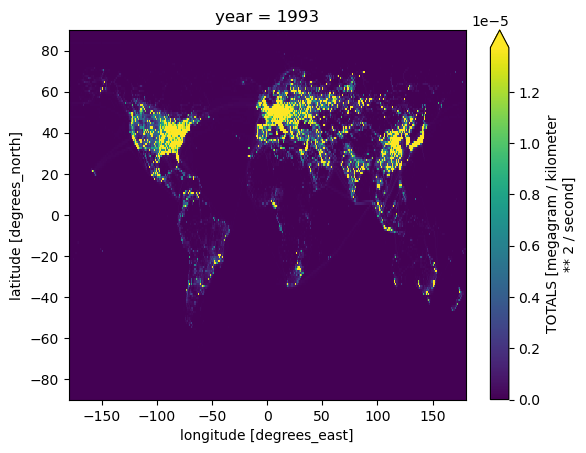

In [25]:
num_years = len(EDGAR_flux['year'])

# do it in a loop bcz constucting the regridder is the expensive part, so don't want to make giant one
aggrigates = []
for year_index in range(num_years):
    # for unknown reasons, regridding (on flux) with ESMF produces different results than manually aggregating (on emissions)
    #aggregate = regridder(EDGAR_flux['flux'][year_index,:,:].pint.to('g / m^2 / s').pint.dequantify()).pint.quantify('g / m^2 / s') 
    ems = EDGAR_flux['emissions'][year_index,:,:].pint.to('Mg').to_numpy()
    aggregate = xr.DataArray(ems.reshape(1800, 360, 10).sum(axis=2).T.reshape(360, 180, 10).sum(axis=2).T, dims=['lat', 'lon']).pint.quantify('Mg')
    aggregate.attrs = aggregate.attrs | EDGAR_flux['emissions'][year_index,:,:].attrs # just glue the attributes back on. probably fine.
    aggrigates.append(aggregate)
    
# CF convention stuffs
EDGAR_aggregated_flux = xr.Dataset()
EDGAR_aggregated_flux['emissions'] = xr.concat(aggrigates, dim='year')
EDGAR_aggregated_flux['cell area'] = xr.DataArray(grid_1x1_areas.to_numpy(), dims=['lat','lon']).pint.quantify('km^2') # force lat/lon to line up
EDGAR_aggregated_flux['seconds_per_year'] = EDGAR_flux['seconds_per_year']

EDGAR_aggregated_flux['flux'] = EDGAR_aggregated_flux['emissions'] / EDGAR_aggregated_flux['cell area'] / EDGAR_aggregated_flux['seconds_per_year']
EDGAR_aggregated_flux['mass_tendency'] = (EDGAR_aggregated_flux['flux'] * EDGAR_aggregated_flux['cell area'] * EDGAR_aggregated_flux['seconds_per_year']).pint.to('Pg')


EDGAR_aggregated_flux.attrs = EDGAR_flux.attrs | {'earth_radius': earth_radius}
EDGAR_aggregated_flux['lon_bounds'] = grid_1x1['lon_bounds']
EDGAR_aggregated_flux['lat_bounds'] = grid_1x1['lat_bounds']
del EDGAR_aggregated_flux['latitude_longitude']
del EDGAR_aggregated_flux['flux'].attrs['year']
del EDGAR_aggregated_flux['flux'].attrs['global_total'] # need to sum
EDGAR_aggregated_flux['mass_tendency'].attrs['longname'] = "Mass of carbon emitted into atmosphere each year by burning fossil fuels, per cell"
EDGAR_aggregated_flux['flux'].attrs['longname'] = "Flux of carbon emitted into atmosphere by burning fossil fuels"

EDGAR_aggregated_flux['normalized_flux'] = EDGAR_aggregated_flux['flux'] / EDGAR_aggregated_flux['flux'].sum(dim=['lat','lon'])
EDGAR_aggregated_flux['normalized_mass_tendency'] = EDGAR_aggregated_flux['mass_tendency'] / EDGAR_aggregated_flux['mass_tendency'].sum(dim=['lat','lon'])

EDGAR_aggregated_flux.pint.dequantify().to_netcdf('processed_inputs/EDGAR_fluxes.nc')
display(EDGAR_aggregated_flux)
EDGAR_aggregated_flux['flux'][0,:,:].plot(robust=True)

#### Dump EDGAR to IDL

In [26]:
import os, sys
current_directory = os.getcwd()

# NOTE: this import fucks with your working directory. Use caution.
correct_dir = os.path.abspath('')
from idlpy import * 
# sys.path.append('/usr/local/nv5/idl/lib/bridges')
# sys.path.append('/Applications/NV5/idl91/lib/bridges')
os.chdir(correct_dir)

IDL 9.1.0 (darwin arm64 m64).
(c) 2024, NV5 Geospatial Solutions, Inc.

Want an IDL Workbench alternative? Check out "IDL for VSCode" for a new user experience.
https://marketplace.visualstudio.com/items?itemName=IDL.idl-for-vscode
 


In [27]:
edgar_array = EDGAR_aggregated_flux['normalized_mass_tendency'].to_numpy().transpose((1,2,0))

IDL.fracarr = edgar_array # do this funky way to specify variable name
IDL.run(command="SAVE, fracarr, FILENAME='processed_inputs/fracarr_2025a.sav'")

### Load countries gridded map

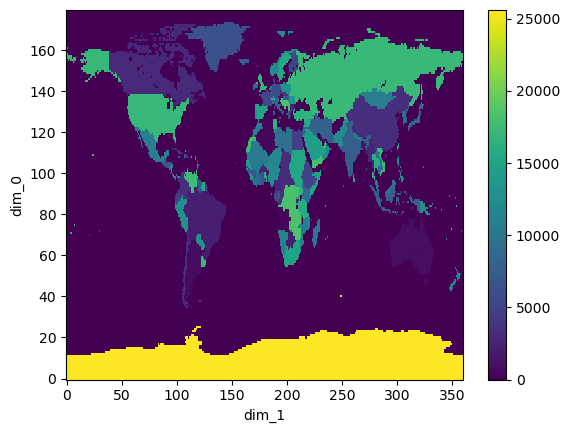

In [28]:
map = np.loadtxt('inputs/COUNTRY1X1.1993.mod.txt', skiprows=3)
map = map.reshape(180, 360)
map = xr.DataArray(map)

codes = pd.read_csv('inputs/COUNTRY1X1.CODE.mod2.2013.csv')
map.plot()

In [29]:
from distutils.sysconfig import get_python_lib
print(get_python_lib())

/opt/anaconda3/envs/p310/lib/python3.10/site-packages
